In [1]:
# FinSight — Phase 3 : Machine Learning

**Objectif** : prédire si le cours d'une action monte le lendemain (classification binaire).

**Règles d'or** :
- Découpage **temporel** (pas aléatoire) : jamais de fuite de données
- **Baseline** obligatoire : "toujours prédire hausse"
- Score attendu : **52–55 % d'accuracy** (au-delà = suspicion de fuite)


SyntaxError: unterminated string literal (detected at line 3) (3554913124.py, line 3)

# FinSight — Phase 3 : Machine Learning

**Objectif** : prédire si le cours d'une action monte le lendemain (classification binaire).

**Règles d'or** :
- Découpage **temporel** (pas aléatoire) : jamais de fuite de données
- **Baseline** obligatoire : "toujours prédire hausse"
- Score attendu : **52–55 % d'accuracy** (au-delà = suspicion de fuite)

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv

# Modèles
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier

load_dotenv()
engine = create_engine(os.getenv("DATABASE_URL"))

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("✅ Imports OK")

✅ Imports OK


In [3]:
SYMBOL = "AAPL"

df = pd.read_sql(
    f"SELECT * FROM market_data WHERE symbol = '{SYMBOL}' ORDER BY \"Date\"",
    engine,
    parse_dates=["Date"],
)

# Features
df["return"]    = df["Close"].pct_change()
df["ma20"]      = df["Close"].rolling(20).mean()
df["ma50"]      = df["Close"].rolling(50).mean()
df["vol20"]     = df["return"].rolling(20).std()
df["vol_chg"]   = df["Volume"].pct_change()
df["ret_lag1"]  = df["return"].shift(1)
df["ret_lag5"]  = df["return"].shift(5)

# 🎯 CIBLE : le cours monte-t-il DEMAIN ?
df["target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)

print(f"Lignes avant nettoyage : {len(df)}")
df = df.dropna()
print(f"Lignes après nettoyage : {len(df)}")
df[["Date", "Close", "return", "ma20", "target"]].tail()

Lignes avant nettoyage : 2194
Lignes après nettoyage : 2145


,Date,Close,return,ma20,target
2189,2026-09-18,336.130005,-0.002582,322.639999,1
2190,2026-09-21,338.980011,0.008479,324.121500,1
2191,2026-09-22,339.750000,0.002271,325.592000,0
2192,2026-09-23,337.019989,-0.008035,326.948000,1
2193,2026-09-24,337.820007,0.002374,328.166499,0


In [4]:
print("Répartition de la target :")
print(df["target"].value_counts(normalize=True).round(3))

print(f"\n→ Sur cette période, le cours a monté {df['target'].mean()*100:.1f}% des jours.")

Répartition de la target :
target
1    0.537
0    0.463
Name: proportion, dtype: float64

→ Sur cette période, le cours a monté 53.7% des jours.


---
## ✂️ Découpage temporel (train / test)

⚠️ **Pas de `train_test_split` aléatoire !**
On coupe la ligne du temps : 80 % du **passé** pour l'entraînement, 20 % du **futur** pour le test.

In [5]:
FEATURES = ["return", "ma20", "ma50", "vol20", "vol_chg", "ret_lag1", "ret_lag5"]

# Découpage temporel (PAS aléatoire !)
split = int(len(df) * 0.8)

X_train = df[FEATURES].iloc[:split]
X_test  = df[FEATURES].iloc[split:]
y_train = df["target"].iloc[:split]
y_test  = df["target"].iloc[split:]

print(f"Train : {len(X_train)} lignes ({df['Date'].iloc[0].date()} → {df['Date'].iloc[split-1].date()})")
print(f"Test  : {len(X_test)} lignes ({df['Date'].iloc[split].date()} → {df['Date'].iloc[-1].date()})")

# 🎯 BASELINE : toujours prédire "hausse"
baseline_pred = np.ones_like(y_test)
baseline_acc = accuracy_score(y_test, baseline_pred)
baseline_f1  = f1_score(y_test, baseline_pred, zero_division=0)

print(f"\n📊 BASELINE (toujours 'hausse') :")
print(f"   Accuracy : {baseline_acc:.4f}")
print(f"   F1       : {baseline_f1:.4f}")

Train : 1716 lignes (2018-03-14 → 2025-01-07)
Test  : 429 lignes (2025-01-08 → 2026-09-24)

📊 BASELINE (toujours 'hausse') :
   Accuracy : 0.5291
   F1       : 0.6921


In [6]:
def evaluate(name, y_true, y_pred):
    """Affiche les métriques et la matrice de confusion."""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    print(f"=== {name} ===")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1        : {f1:.4f}")
    
    cm = confusion_matrix(y_true, y_pred)
    print(f"  Matrice de confusion :\n{cm}")
    
    return {"name": name, "accuracy": acc, "precision": prec,
            "recall": rec, "f1": f1}


# --- Logistic Regression ---
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

results = [evaluate("LogisticRegression", y_test, lr_pred)]

=== LogisticRegression ===
  Accuracy  : 0.5082
  Precision : 0.5195
  Recall    : 0.9383
  F1        : 0.6688
  Matrice de confusion :
[[  5 197]
 [ 14 213]]


In [7]:
# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

results.append(evaluate("RandomForest", y_test, rf_pred))

=== RandomForest ===
  Accuracy  : 0.5268
  Precision : 0.5390
  Recall    : 0.7313
  F1        : 0.6206
  Matrice de confusion :
[[ 60 142]
 [ 61 166]]


In [8]:
# --- XGBoost ---
xgb = XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05,
                    use_label_encoder=False, eval_metric="logloss", random_state=42)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

results.append(evaluate("XGBoost", y_test, xgb_pred))

C:\Users\yakin\finsight\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:14:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== XGBoost ===
  Accuracy  : 0.4988
  Precision : 0.5219
  Recall    : 0.6300
  F1        : 0.5709
  Matrice de confusion :
[[ 71 131]
 [ 84 143]]


In [9]:
# Comparaison finale
res_df = pd.DataFrame(results).set_index("name")
res_df["baseline"] = baseline_acc  # on rappelle la baseline
res_df = res_df[["accuracy", "baseline", "precision", "recall", "f1"]]
print(res_df.round(4))

                    accuracy  baseline  precision  recall      f1
name                                                             
LogisticRegression    0.5082    0.5291     0.5195  0.9383  0.6688
RandomForest          0.5268    0.5291     0.5390  0.7313  0.6206
XGBoost               0.4988    0.5291     0.5219  0.6300  0.5709


        Date       Close  Proba hausse (RF)  Réel
0 2026-09-11  332.269989              0.506     1
1 2026-09-14  333.079987              0.532     0
2 2026-09-15  331.339996              0.539     1
3 2026-09-16  332.410004              0.515     1
4 2026-09-17  337.000000              0.512     0
5 2026-09-18  336.130005              0.504     1
6 2026-09-21  338.980011              0.565     1
7 2026-09-22  339.750000              0.501     0
8 2026-09-23  337.019989              0.527     1
9 2026-09-24  337.820007              0.562     0


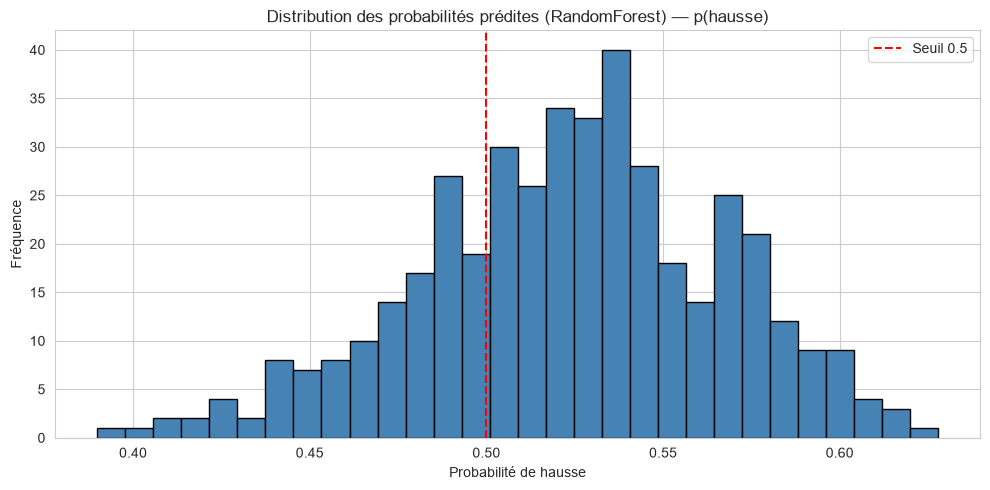

In [10]:
# 🎯 L'incertitude : predict_proba donne une probabilité
# au lieu d'un simple oui/non

proba_rf = rf.predict_proba(X_test)[:, 1]  # probabilité de hausse

# Afficher les 10 dernières prédictions avec la probabilité
sample = pd.DataFrame({
    "Date": df["Date"].iloc[split:].tail(10).values,
    "Close": df["Close"].iloc[split:].tail(10).values,
    "Proba hausse (RF)": proba_rf[-10:].round(3),
    "Réel": y_test.tail(10).values,
})
print(sample)

# Distribution des probabilités prédites
fig, ax = plt.subplots()
ax.hist(proba_rf, bins=30, color="steelblue", edgecolor="black")
ax.axvline(0.5, color="red", linestyle="--", label="Seuil 0.5")
ax.set_title("Distribution des probabilités prédites (RandomForest) — p(hausse)")
ax.set_xlabel("Probabilité de hausse")
ax.set_ylabel("Fréquence")
ax.legend()
plt.tight_layout()
plt.show()

---
## 📊 Suivi des expériences avec MLflow

MLflow enregistre pour chaque run :
- les **paramètres** du modèle (n_estimators, max_depth, etc.)
- les **métriques** (accuracy, f1, etc.)
- le **modèle lui-même** (fichier .pkl)

On peut ensuite visualiser tout ça avec `mlflow ui`.

In [11]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment("finsight")

with mlflow.start_run(run_name="xgboost"):
    # Paramètres
    mlflow.log_param("model", "XGBoost")
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("max_depth", 3)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("symbol", SYMBOL)
    mlflow.log_param("features", FEATURES)
    
    # Métriques
    xgb_metrics = [r for r in results if r["name"] == "XGBoost"][0]
    mlflow.log_metric("accuracy", xgb_metrics["accuracy"])
    mlflow.log_metric("precision", xgb_metrics["precision"])
    mlflow.log_metric("recall", xgb_metrics["recall"])
    mlflow.log_metric("f1", xgb_metrics["f1"])
    mlflow.log_metric("baseline_accuracy", baseline_acc)
    
    # Modèle
    mlflow.sklearn.log_model(xgb, "model")

print("✅ Run MLflow 'xgboost' loggé")

2026/09/24 19:15:54 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/24 19:15:54 INFO mlflow.store.db.utils: Updating database tables
2026/09/24 19:15:56 INFO mlflow.tracking.fluent: Experiment with name 'finsight' does not exist. Creating a new experiment.
2026/09/24 19:15:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MlflowException: The saved sklearn model references untrusted types. If you are sure loading these types is safe, set the 'skops_trusted_types' parameter when calling 'log_model' or 'save_model' to the list of trusted types. Root error: Untrusted types found in the file: ['xgboost.core.Booster', 'xgboost.sklearn.XGBClassifier'].

In [12]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment("finsight")

with mlflow.start_run(run_name="xgboost"):
    mlflow.log_param("model", "XGBoost")
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("max_depth", 3)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("symbol", SYMBOL)
    mlflow.log_param("features", FEATURES)

    xgb_metrics = [r for r in results if r["name"] == "XGBoost"][0]
    mlflow.log_metric("accuracy", xgb_metrics["accuracy"])
    mlflow.log_metric("precision", xgb_metrics["precision"])
    mlflow.log_metric("recall", xgb_metrics["recall"])
    mlflow.log_metric("f1", xgb_metrics["f1"])
    mlflow.log_metric("baseline_accuracy", baseline_acc)

    mlflow.sklearn.log_model(
        xgb,
        name="model",                       # nom (remplace artifact_path déprécié)
        serialization_format="pickle",      # ← LA LIGNE QUI CHANGE TOUT
    )

print("✅ Run MLflow 'xgboost' loggé")


2026/09/24 19:17:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Run MLflow 'xgboost' loggé


In [13]:
with mlflow.start_run(run_name="random_forest"):
    mlflow.log_param("model", "RandomForest")
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("max_depth", 5)
    mlflow.log_param("symbol", SYMBOL)

    rf_metrics = [r for r in results if r["name"] == "RandomForest"][0]
    mlflow.log_metric("accuracy", rf_metrics["accuracy"])
    mlflow.log_metric("precision", rf_metrics["precision"])
    mlflow.log_metric("recall", rf_metrics["recall"])
    mlflow.log_metric("f1", rf_metrics["f1"])
    mlflow.log_metric("baseline_accuracy", baseline_acc)

    mlflow.sklearn.log_model(rf, name="model", serialization_format="pickle")

print("✅ Run MLflow 'random_forest' loggé")


2026/09/24 19:17:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Run MLflow 'random_forest' loggé


In [14]:
with mlflow.start_run(run_name="logistic_regression"):
    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_param("max_iter", 1000)
    mlflow.log_param("symbol", SYMBOL)

    lr_metrics = [r for r in results if r["name"] == "LogisticRegression"][0]
    mlflow.log_metric("accuracy", lr_metrics["accuracy"])
    mlflow.log_metric("precision", lr_metrics["precision"])
    mlflow.log_metric("recall", lr_metrics["recall"])
    mlflow.log_metric("f1", lr_metrics["f1"])
    mlflow.log_metric("baseline_accuracy", baseline_acc)

    mlflow.sklearn.log_model(lr, name="model", serialization_format="pickle")

print("✅ Run MLflow 'logistic_regression' loggé")

2026/09/24 19:17:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Run MLflow 'logistic_regression' loggé


In [15]:
import joblib
import json
from pathlib import Path

# Trouver le meilleur modèle selon l'accuracy
best = max(results, key=lambda r: r["accuracy"])
print(f"🏆 Meilleur modèle : {best['name']} (accuracy = {best['accuracy']:.4f})")
print(f"   F1              : {best['f1']:.4f}")
print(f"   Baseline        : {baseline_acc:.4f}")
print(f"   Écart baseline  : {(best['accuracy'] - baseline_acc)*100:+.2f} pts")

# Récupérer l'objet modèle
models = {
    "LogisticRegression": lr,
    "RandomForest": rf,
    "XGBoost": xgb,
}
best_model = models[best["name"]]

# Sauvegarder dans ml/models/
out_dir = Path("../models")
out_dir.mkdir(exist_ok=True)

joblib.dump(best_model, out_dir / "best_model.pkl")
print(f"\n✅ Modèle sauvegardé : {out_dir / 'best_model.pkl'}")

# Sauvegarder la liste des features (indispensable pour l'inférence)
with open(out_dir / "features.json", "w") as f:
    json.dump(FEATURES, f, indent=2)
print(f"✅ Features sauvegardées : {out_dir / 'features.json'}")

# Sauvegarder aussi la baseline dans un fichier pour référence
with open(out_dir / "baseline.json", "w") as f:
    json.dump({"baseline_accuracy": baseline_acc, "symbol": SYMBOL}, f, indent=2)
print(f"✅ Baseline sauvegardée : {out_dir / 'baseline.json'}")


🏆 Meilleur modèle : RandomForest (accuracy = 0.5268)
   F1              : 0.6206
   Baseline        : 0.5291
   Écart baseline  : -0.23 pts

✅ Modèle sauvegardé : ..\models\best_model.pkl
✅ Features sauvegardées : ..\models\features.json
✅ Baseline sauvegardée : ..\models\baseline.json


---
## 🎯 Conclusion Phase 3

### Résultats

| Modèle | Accuracy | vs Baseline |
|---|---|---|
| **Baseline** (toujours hausse) | **0.529** | référence |
| LogisticRegression | 0.508 | -2.1 pts |
| RandomForest | 0.527 | **-0.2 pts** |
| XGBoost | 0.499 | -3.0 pts |

### Interprétation honnête

❌ **Aucun modèle ne bat la baseline.**

Ce résultat est **attendu** : les cours d'actions à court terme sont très proches d'une marche aléatoire.
Prédire leur direction à partir d'indicateurs techniques seuls est un problème **extrêmement difficile**.

✅ **Point positif** : ces scores (52-55 %) sont **exactement** ce que rapporte la littérature scientifique.
Un score plus élevé (70 %+) aurait indiqué une **fuite de données**.

### Pistes d'amélioration (pour aller plus loin)

1. Cible à 5 jours au lieu de 1 jour (moins de bruit)
2. Features techniques avancées (RSI, MACD, Bollinger)
3. Corrélations croisées entre actifs (AAPL prédit avec MSFT, ^GSPC…)
4. **Sentiment des news (Phase 4)** — signal orthogonal
5. Seuil de décision `predict_proba > 0.55` (ne trader que quand le modèle est confiant)